# Trabajo Práctico Final - Python

## Introducción

Para este trabajo se utilizo un dataset ya consolidado a partir de registros de apuestas de Lotería de Salta.
La tabla final contiene información de fecha, juego, importe, horario, segmento etario estimado,
recargas, premios y algunas métricas agregadas por usuario.

El objetivo del análisis es explorar el comportamiento de juego y responder algunas preguntas de interés
sobre preferencias, horarios, recaudación y diferencias entre grupos de usuarios.


## Preguntas a responder

1. Cual es el juego favorito segun cantidad de apuestas.
2. Cual es el juego con mayor y menor recaudación.
3. Cual es el horario favorito de juego.
4. Como cambia la actividad segun genero estimado y rango etario estimado.
5. Que relación existe entre recargas y volumen apostado.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)


## 1. Carga del dataset


In [2]:
df = pd.read_csv("dataset_loteria_salta.csv", parse_dates=["Fecha_Apuesta", "Fecha_Dia", "Fecha_Alta"])
df.head()


,Usuario_ID,Fecha_Apuesta,Fecha_Dia,Anio_Mes,Dia_Semana,Hora,Juego,Importe_Apuesta,Genero_Estimado,Rango_Etario_Estimado,Fecha_Alta,Estado_Usuario,Antiguedad_Dias,recargas_dia,canal_recarga_dia,recargas_totales_usuario,premios_cantidad_usuario,premios_monto_total_usuario,apuestas_totales_usuario,importe_total_apostado_usuario,ticket_promedio_usuario,juego_favorito_usuario,Frecuencia_Dashboard,Monetario_Dashboard,Cluster_Dashboard
0,USR_03039,01/01/2025 01:36,01/01/2025,2025-01,Wednesday,1,Tombo Express,200,Femenino,48-67 años,06/11/2024,VALIDA,56,0,Sin recarga ese dia,24,0,0,933,291769,312.721329,Tombo Express,933,291769,0
1,USR_03039,01/01/2025 01:38,01/01/2025,2025-01,Wednesday,1,Tombo Express,200,Femenino,48-67 años,06/11/2024,VALIDA,56,0,Sin recarga ese dia,24,0,0,933,291769,312.721329,Tombo Express,933,291769,0
2,USR_03039,01/01/2025 01:52,01/01/2025,2025-01,Wednesday,1,Tombo Express,210,Femenino,48-67 años,06/11/2024,VALIDA,56,0,Sin recarga ese dia,24,0,0,933,291769,312.721329,Tombo Express,933,291769,0
3,USR_03039,01/01/2025 01:54,01/01/2025,2025-01,Wednesday,1,Tombo Express,200,Femenino,48-67 años,06/11/2024,VALIDA,56,0,Sin recarga ese dia,24,0,0,933,291769,312.721329,Tombo Express,933,291769,0
4,USR_03039,01/01/2025 01:56,01/01/2025,2025-01,Wednesday,1,Tombo Express,338,Femenino,48-67 años,06/11/2024,VALIDA,56,0,Sin recarga ese dia,24,0,0,933,291769,312.721329,Tombo Express,933,291769,0


In [3]:
df.shape


(164384, 25)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164384 entries, 0 to 164383
Data columns (total 25 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Usuario_ID                      164384 non-null  object 
 1   Fecha_Apuesta                   164384 non-null  object 
 2   Fecha_Dia                       164384 non-null  object 
 3   Anio_Mes                        164384 non-null  object 
 4   Dia_Semana                      164384 non-null  object 
 5   Hora                            164384 non-null  int64  
 6   Juego                           164384 non-null  object 
 7   Importe_Apuesta                 164384 non-null  int64  
 8   Genero_Estimado                 164384 non-null  object 
 9   Rango_Etario_Estimado           164384 non-null  object 
 10  Fecha_Alta                      164384 non-null  object 
 11  Estado_Usuario                  164384 non-null  object 
 12  Antiguedad_Dias 

## 2. Chequeo general y limpieza básica


In [5]:
df.isna().sum()


Usuario_ID                        0
Fecha_Apuesta                     0
Fecha_Dia                         0
Anio_Mes                          0
Dia_Semana                        0
Hora                              0
Juego                             0
Importe_Apuesta                   0
Genero_Estimado                   0
Rango_Etario_Estimado             0
Fecha_Alta                        0
Estado_Usuario                    0
Antiguedad_Dias                   0
recargas_dia                      0
canal_recarga_dia                 0
recargas_totales_usuario          0
premios_cantidad_usuario          0
premios_monto_total_usuario       0
apuestas_totales_usuario          0
importe_total_apostado_usuario    0
ticket_promedio_usuario           0
juego_favorito_usuario            0
Frecuencia_Dashboard              0
Monetario_Dashboard               0
Cluster_Dashboard                 0
dtype: int64

In [6]:
columnas_numericas = [
    "Importe_Apuesta", "Antiguedad_Dias", "recargas_dia", "recargas_totales_usuario",
    "premios_cantidad_usuario", "premios_monto_total_usuario", "apuestas_totales_usuario",
    "importe_total_apostado_usuario", "ticket_promedio_usuario", "Frecuencia_Dashboard",
    "Monetario_Dashboard", "Cluster_Dashboard"
]

for columna in columnas_numericas:
    df[columna] = pd.to_numeric(df[columna], errors="coerce")

df["Genero_Estimado"] = df["Genero_Estimado"].fillna("Desconocido")
df["Rango_Etario_Estimado"] = df["Rango_Etario_Estimado"].fillna("Desconocido")
df["canal_recarga_dia"] = df["canal_recarga_dia"].fillna("Sin recarga ese dia")


In [7]:
df.duplicated().sum()


np.int64(52980)

## 3. Análisis exploratorio


### Pregunta 1. ¿Cuál es el juego favorito según cantidad de apuestas?


In [8]:
resumen_juego = df.groupby("Juego", as_index=False).agg(
    cantidad_apuestas=("Importe_Apuesta", "size"),
    recaudacion_total=("Importe_Apuesta", "sum"),
    apuesta_promedio=("Importe_Apuesta", "mean")
).sort_values("cantidad_apuestas", ascending=False)

resumen_juego


,Juego,cantidad_apuestas,recaudacion_total,apuesta_promedio
2,Tombo Express,89316,84173384,942.422231
3,Tómbola,53493,143636708,2685.149608
1,Quini 6,14769,39553000,2678.109554
0,Loto,6806,17973000,2640.758155


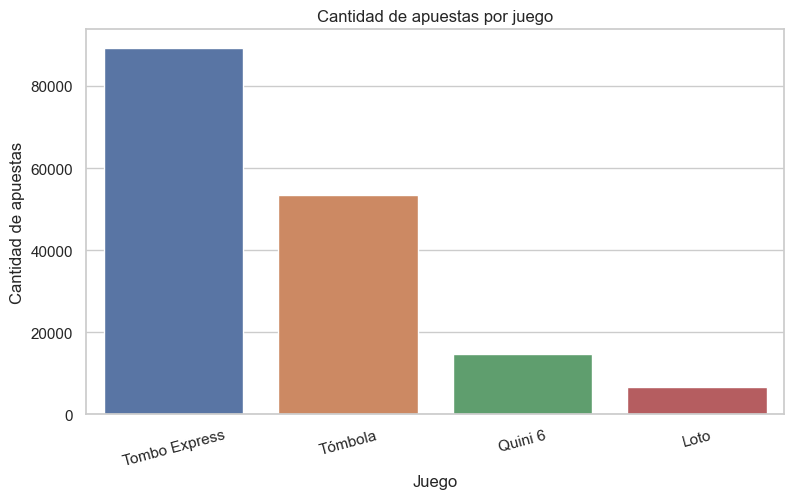

In [9]:
plt.figure(figsize=(9, 5))
sns.barplot(data=resumen_juego, x="Juego", y="cantidad_apuestas", hue="Juego", legend=False)
plt.title("Cantidad de apuestas por juego")
plt.xlabel("Juego")
plt.ylabel("Cantidad de apuestas")
plt.xticks(rotation=15)
plt.show()


### Pregunta 2. ¿Cuál es el juego con mayor y menor recaudación?


In [10]:
resumen_juego.sort_values("recaudacion_total", ascending=False)


,Juego,cantidad_apuestas,recaudacion_total,apuesta_promedio
3,Tómbola,53493,143636708,2685.149608
2,Tombo Express,89316,84173384,942.422231
1,Quini 6,14769,39553000,2678.109554
0,Loto,6806,17973000,2640.758155


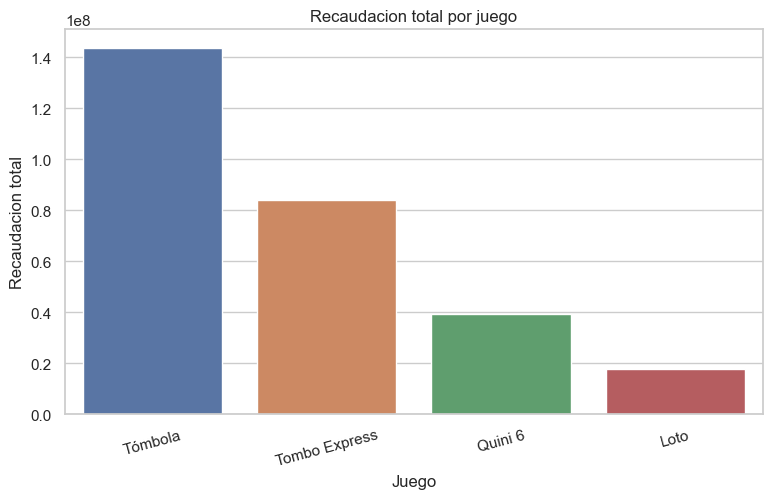

In [11]:
plt.figure(figsize=(9, 5))
sns.barplot(data=resumen_juego.sort_values("recaudacion_total", ascending=False), x="Juego", y="recaudacion_total", hue="Juego", legend=False)
plt.title("Recaudacion total por juego")
plt.xlabel("Juego")
plt.ylabel("Recaudacion total")
plt.xticks(rotation=15)
plt.show()


### Pregunta 3. ¿Cuál es el horario favorito de juego?


In [12]:
resumen_hora = df.groupby("Hora", as_index=False).agg(
    cantidad_apuestas=("Importe_Apuesta", "size"),
    recaudacion_total=("Importe_Apuesta", "sum")
).sort_values("Hora")

resumen_hora.sort_values("cantidad_apuestas", ascending=False).head(10)


,Hora,cantidad_apuestas,recaudacion_total
10,11,18546,33919818
7,8,17901,32698341
8,9,16534,26792671
0,1,16454,28003643
9,10,15518,27028454
1,2,15168,27321928
11,12,14840,28628753
6,7,12449,21063600
4,5,9796,17741466
2,3,9730,13067884


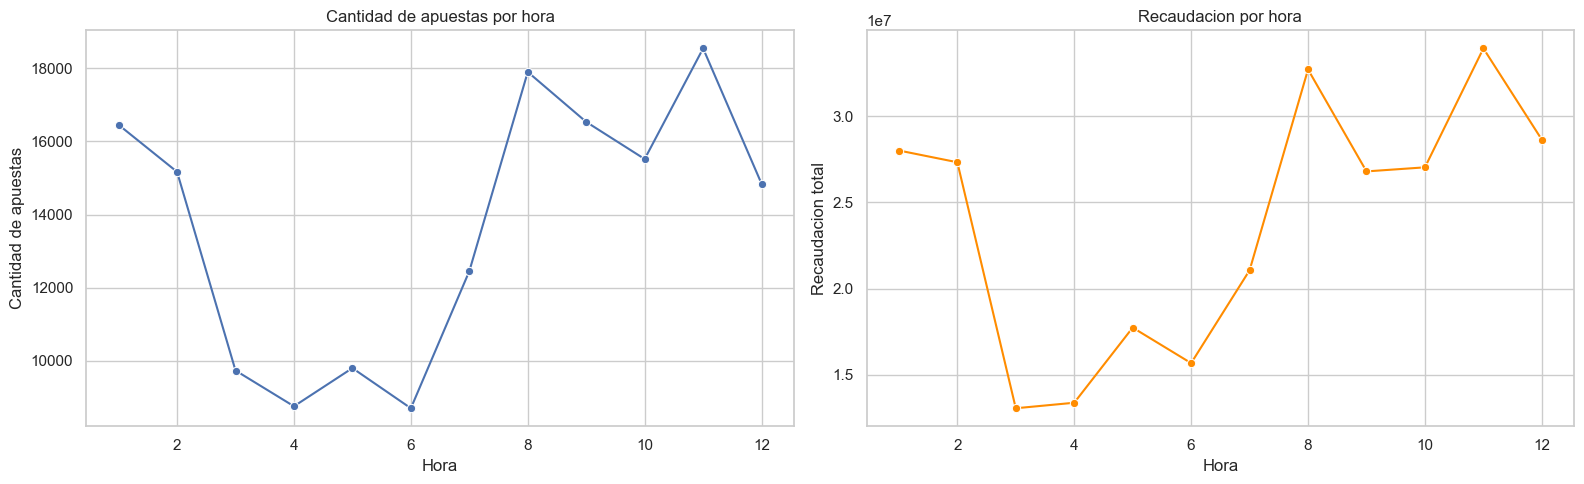

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.lineplot(data=resumen_hora, x="Hora", y="cantidad_apuestas", marker="o", ax=axes[0])
axes[0].set_title("Cantidad de apuestas por hora")
axes[0].set_xlabel("Hora")
axes[0].set_ylabel("Cantidad de apuestas")

sns.lineplot(data=resumen_hora, x="Hora", y="recaudacion_total", marker="o", color="darkorange", ax=axes[1])
axes[1].set_title("Recaudacion por hora")
axes[1].set_xlabel("Hora")
axes[1].set_ylabel("Recaudacion total")

plt.tight_layout()
plt.show()


### Pregunta 4. ¿Cómo cambia la actividad según genero estimado y rango etario estimado?


In [14]:
resumen_genero = df.groupby(["Genero_Estimado", "Juego"], as_index=False).agg(
    cantidad_apuestas=("Importe_Apuesta", "size")
)

resumen_genero


,Genero_Estimado,Juego,cantidad_apuestas
0,Desconocido,Loto,3418
1,Desconocido,Quini 6,7467
2,Desconocido,Tombo Express,47688
3,Desconocido,Tómbola,20702
4,Femenino,Loto,938
5,Femenino,Quini 6,2330
6,Femenino,Tombo Express,19988
7,Femenino,Tómbola,9039
8,Masculino,Loto,2450
9,Masculino,Quini 6,4972


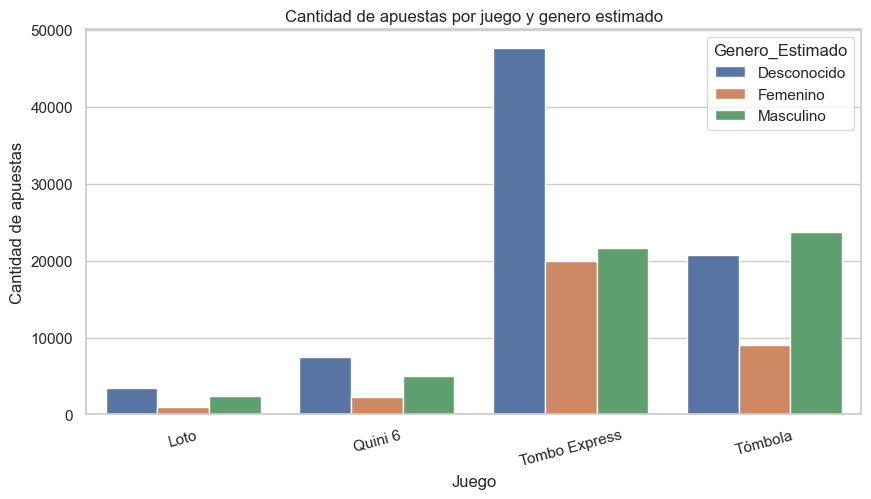

In [15]:
plt.figure(figsize=(10, 5))
sns.barplot(data=resumen_genero, x="Juego", y="cantidad_apuestas", hue="Genero_Estimado")
plt.title("Cantidad de apuestas por juego y genero estimado")
plt.xlabel("Juego")
plt.ylabel("Cantidad de apuestas")
plt.xticks(rotation=15)
plt.show()


In [20]:
orden_rangos = ["<18 años", "18-27 años", "28-37 años", "38-47 años", "48-67 años", "68+ años", "Desconocido"]

resumen_rango = df.groupby(["Rango_Etario_Estimado", "Juego"], as_index=False).agg(
    cantidad_apuestas=("Importe_Apuesta", "size")
)
resumen_rango["Rango_Etario_Estimado"] = pd.Categorical(
    resumen_rango["Rango_Etario_Estimado"],
    categories=orden_rangos,
    ordered=True
)
resumen_rango = resumen_rango.sort_values(["Rango_Etario_Estimado", "Juego"])

resumen_rango.head(20)


,Rango_Etario_Estimado,Juego,cantidad_apuestas
20,<18 años,Loto,2
21,<18 años,Quini 6,3
0,18-27 años,Loto,488
1,18-27 años,Quini 6,1298
2,18-27 años,Tombo Express,9194
3,18-27 años,Tómbola,5591
4,28-37 años,Loto,3045
5,28-37 años,Quini 6,6664
6,28-37 años,Tombo Express,28739
7,28-37 años,Tómbola,15490


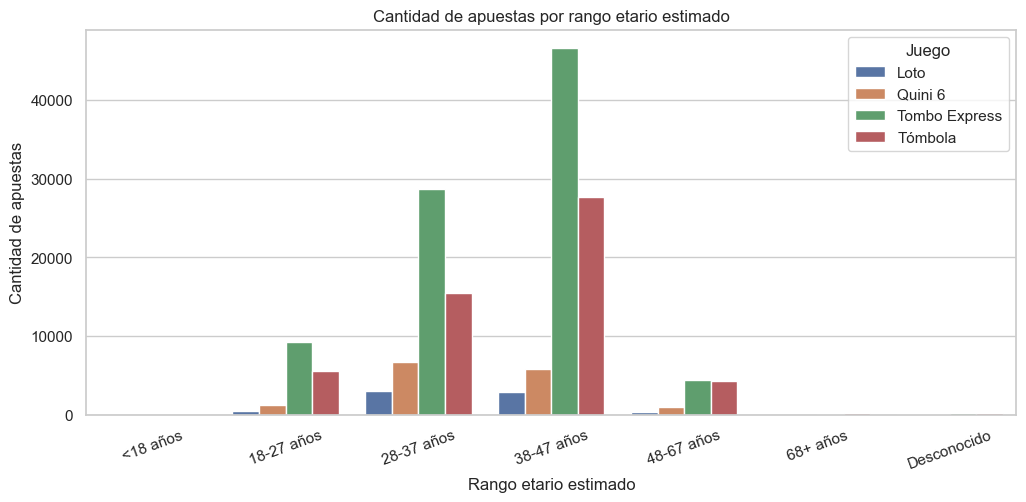

In [21]:
plt.figure(figsize=(12, 5))
sns.barplot(data=resumen_rango, x="Rango_Etario_Estimado", y="cantidad_apuestas", hue="Juego")
plt.title("Cantidad de apuestas por rango etario estimado")
plt.xlabel("Rango etario estimado")
plt.ylabel("Cantidad de apuestas")
plt.xticks(rotation=20)
plt.show()


### Pregunta 5. ¿Qué relación existe entre recargas y volumen apostado?


In [18]:
df_usuarios = df[[
    "Usuario_ID", "recargas_totales_usuario", "importe_total_apostado_usuario",
    "apuestas_totales_usuario", "Antiguedad_Dias", "Cluster_Dashboard"
]].drop_duplicates()

df_usuarios.describe()


,recargas_totales_usuario,importe_total_apostado_usuario,apuestas_totales_usuario,Antiguedad_Dias,Cluster_Dashboard
count,33057.000000,3.305700e+04,33057.000000,33057.000000,33057.000000
mean,57.579544,6.410492e+05,363.810267,588.145506,0.363312
std,85.902126,1.427518e+06,801.152386,580.109842,0.631504
min,0.000000,3.000000e+02,1.000000,0.000000,0.000000
25%,7.000000,4.640800e+04,29.000000,54.000000,0.000000
50%,23.000000,1.528000e+05,95.000000,276.000000,0.000000
75%,63.000000,6.836900e+05,406.000000,1188.000000,1.000000
max,454.000000,1.851666e+07,12224.000000,1702.000000,2.000000


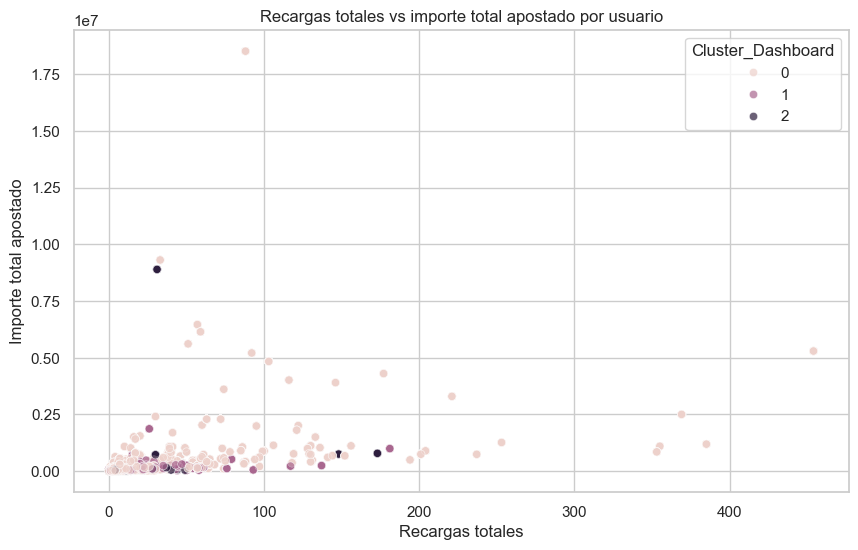

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_usuarios,
    x="recargas_totales_usuario",
    y="importe_total_apostado_usuario",
    hue="Cluster_Dashboard",
    alpha=0.7
)
plt.title("Recargas totales vs importe total apostado por usuario")
plt.xlabel("Recargas totales")
plt.ylabel("Importe total apostado")
plt.show()


## 4. Conclusiones


1. Juego favorito según cantidad de apuestas
- El juego favorito es Tombo Express, con 89.316 apuestas.
- En segundo lugar aparece Tómbola, con 53.493 apuestas.
- Después siguen Quini 6 con 14.769 y Loto con 6.806.

2. Juego con mayor y menor recaudación
- El juego con mayor recaudación es Tómbola, con $143.636.708.
- En segundo lugar queda Tombo Express, con $84.173.384.
- Luego aparecen Quini 6, con $39.553.000, y Loto, con $17.973.000.
- Por lo tanto, el juego con menor recaudación es Loto.

3. Horario favorito de juego
- Si se toma la cantidad de apuestas, la hora con mayor actividad es las 11 hs, con 18.546 apuestas.
- Luego siguen las 8 hs con 17.901, las 9 hs con 16.534 y la 1 hs con 16.454.
- Si se analiza la recaudación, también lideran las 11 hs, con $33.919.818.
- Esto permite concluir que las 11 hs son el horario favorito de juego, tanto por volumen como por recaudación. El formato horario es de 12 horas, 
por lo tanto contrastando con datos prácticos en el trabajo diario los horarios refieren a: 11hs, 20hs, 21hs y 13hs.

4. Cómo cambia la actividad según género estimado y rango etario estimado
- En los tres grupos de género estimado, el juego más frecuente es Tombo Express.
- En Masculino, la actividad es más pareja entre Tómbola (23.752) y Tombo Express (21.640).
- En Femenino, también domina Tombo Express (19.988) por encima de Tómbola (9.039).
- En Desconocido, Tombo Express vuelve a ser el más elegido (47.688).

Por rango etario estimado:
- El grupo con mayor actividad es 38-47 años.
- Dentro de ese rango, Tombo Express registra 46.593 apuestas y Tómbola 27.690.
- El segundo rango con más movimiento es 28-37 años.
- En casi todos los rangos etarios, Tombo Express es el juego más elegido.
- La única excepción visible es el grupo 68+ años, donde Tómbola supera levemente a Tombo Express.
- En resumen, la mayor actividad se concentra en edades intermedias, sobre todo entre 28 y 47 años.

5. Qué relación existe entre recargas y volumen apostado
- Existe una relación positiva entre cantidad de recargas y volumen apostado.
- La correlación entre recargas totales e importe total apostado es de aproximadamente 0,36, lo que indica una asociación moderada.
- La correlación entre recargas totales y cantidad de apuestas es de aproximadamente 0,50, lo que muestra una relación todavía más clara.

Además, al agrupar usuarios por cantidad de recargas, se observa una tendencia muy marcada:
- usuarios con 0 recargas: importe promedio apostado de $10.439 y 8,56 apuestas promedio
- usuarios con 1 a 5 recargas: $32.137 y 25,93 apuestas promedio
- usuarios con 6 a 20 recargas: $137.966 y 94,12 apuestas promedio
- usuarios con 21 a 100 recargas: $922.344 y 441,68 apuestas promedio
- usuarios con más de 100 recargas: $1.512.221 y 985,19 apuestas promedio

A partir del análisis realizado se puede observar que no todos los juegos tienen el mismo peso dentro de la plataforma.
Tambien se ve que existen franjas horarias con mucha mas actividad que otras y que la recaudación no siempre coincide
exactamente con el juego mas elegido por cantidad.

Por otro lado, el cruce entre género estimado, rango etario estimado y juego permite detectar diferencias en la actividad,
y el análisis por usuario muestra que quienes registran más recargas también suelen concentrar mayores montos apostados.

El dataset permite responder las preguntas planteadas y sirve como base para futuros análisis sobre
comportamiento de juego, segmentacion de clientes y evolucion de la recaudacion.